In [1]:
import pybaseball
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import arviz as az
import pandas as pd

In [2]:
from pybaseball import batting_stats

In [3]:
data = batting_stats(2017, 2018)
data["Team"]

0      BOS
1      LAA
3      NYY
16     HOU
51     CLE
      ... 
271    HOU
274    DET
257    BAL
269    LAA
284    BAL
Name: Team, Length: 285, dtype: str

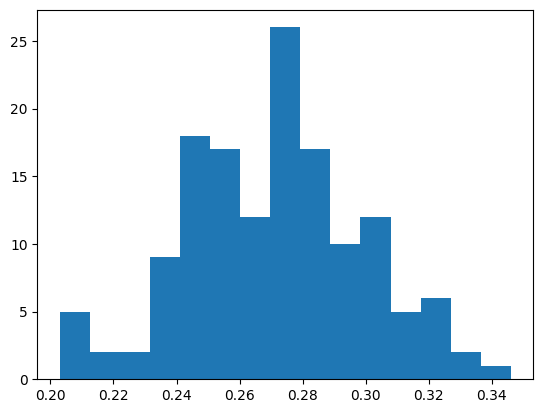

In [4]:
plt.hist(data[data["Season"] == 2017]["AVG"], bins=15)
plt.show()

In [5]:
mat = data[["Season", "AVG"]]
mat.sort_values(by=["Season"], inplace=True, ascending=True)
mat

,Season,AVG
269,2017,0.241
257,2017,0.234
3,2017,0.284
271,2017,0.231
259,2017,0.203
...,...,...
274,2018,0.251
16,2018,0.286
1,2018,0.312
284,2018,0.168


In [6]:
X = mat["Season"]
y = mat["AVG"]
X

269    2017
257    2017
3      2017
271    2017
259    2017
       ... 
274    2018
16     2018
1      2018
284    2018
0      2018
Name: Season, Length: 285, dtype: int64

In [7]:
data_2 = batting_stats(2019, 2020)

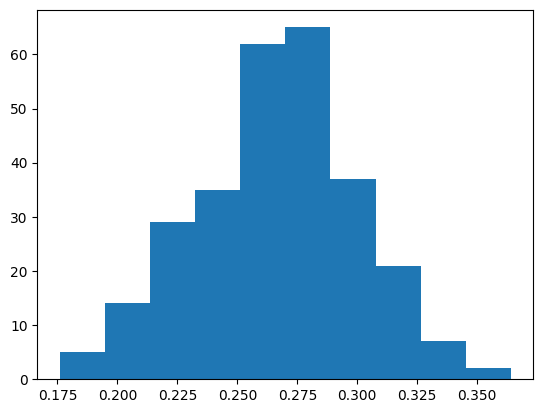

In [8]:
plt.hist(data_2["AVG"])
plt.show()

In [37]:
np.log10(data["AVG"].mean())

np.float64(-0.5803456900066666)

In [38]:
np.log10(data_2["AVG"].mean())

np.float64(-0.5739940328837199)

In [39]:
!uv add pymc

Resolved 141 packages in 858ms                                       
Prepared 7 packages in 5.86s                                             
Installed 22 packages in 40ms                               
 + arviz==0.23.4
 + cachetools==6.2.6
 + cloudpickle==3.1.2
 + cons==0.4.7
 + etuples==0.3.10
 + filelock==3.25.0
 + h5netcdf==1.8.1
 + h5py==3.16.0
 + llvmlite==0.46.0
 + logical-unification==0.4.7
 + markdown-it-py==4.0.0
 + mdurl==0.1.2
 + minikanren==1.0.5
 + multipledispatch==1.0.0
 + numba==0.64.0
 + pymc==5.28.1
 + pytensor==2.38.2
 + rich==14.3.3
 + threadpoolctl==3.6.0
 + toolz==1.1.0
 + xarray==2026.2.0
 + xarray-einstats==0.10.0


In [41]:
y = data["AVG"]
y.head()

31    0.328
5     0.313
15    0.282
3     0.309
50    0.266
Name: AVG, dtype: float64

In [28]:
import pymc as pm

basic_model = pm.Model()

with basic_model:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=1)
    mu = alpha + beta * X
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=y)
    idata = pm.sample(cores=4)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

/home/user/baseball/.venv/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 170 seconds.
There were 306 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


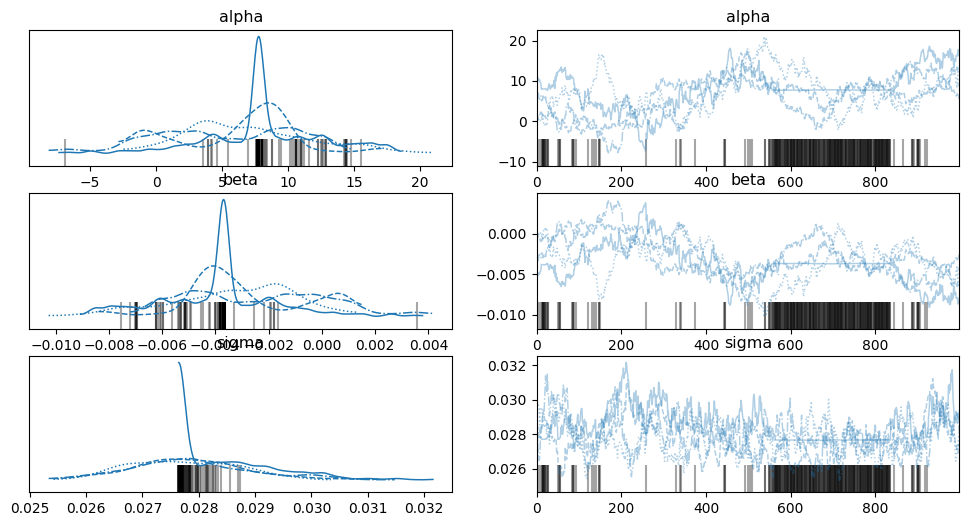

In [48]:
az.plot_trace(idata);

In [50]:
az.summary(idata, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,6.59,4.98,-2.55,15.88,0.98,0.46,27.06,59.68,1.14
beta,-0.00,0.00,-0.01,0.00,0.00,0.00,27.06,59.63,1.14
sigma,0.03,0.00,0.03,0.03,0.00,0.00,33.61,126.00,1.10


# MODEL 0 

In [4]:
data_m0 = data[["Age", "SLG", "Barrel%", "OBP", "HardHit%"]]
# normalizing the age value
ages_normal = (data["Age"] - data["Age"].mean()) / data["Age"].std()
data_m0["Age"] = ages_normal
data_m0.head()

,Age,SLG,Barrel%,OBP,HardHit%
0,-0.894378,0.640,0.141,0.438,0.502
1,-0.624359,0.628,0.165,0.460,0.460
3,-0.894378,0.627,0.257,0.422,0.550
16,-1.164397,0.532,0.076,0.394,0.398
51,-1.164397,0.519,0.093,0.352,0.405


In [5]:
# targetting batting avg
data_model_0 = data[data["Season"] == 2017]
data_model_0.shape

(144, 320)

In [6]:
# target from 2017 season
y = data_model_0["AVG"]

In [7]:
## 144 samples, fairly small
data_model_0 = data_model_0[["Age", "PA", "OBP", "SLG", "Barrel%", "HardHit%"]]
data_model_0.head

<bound method NDFrame.head of      Age   PA    OBP    SLG  Barrel%  HardHit%
3     25  678  0.422  0.627    0.257     0.550
10    27  662  0.410  0.547    0.067     0.284
15    24  645  0.374  0.583    0.050     0.345
13    25  665  0.409  0.537    0.096     0.370
2     25  507  0.442  0.629    0.133     0.405
..   ...  ...    ...    ...      ...       ...
281   33  541  0.293  0.315    0.045     0.309
259   36  686  0.308  0.366    0.066     0.356
271   40  509  0.283  0.383    0.046     0.313
257   31  603  0.289  0.397    0.068     0.377
269   37  636  0.286  0.386    0.054     0.391

[144 rows x 6 columns]>

In [8]:
# computing beta means
means = data_model_0.mean()
means

Age          28.402778
PA          604.069444
OBP           0.342660
SLG           0.463306
Barrel%       0.072167
HardHit%      0.359500
dtype: float64

In [9]:
# normalizing PA value so it fits ranges
data_model_0["PA"] = (data_model_0["PA"] - data_model_0["PA"].mean()) / data_model_0[
    "PA"
].std()
means = data_model_0.mean()
means

Age         2.840278e+01
PA         -2.220446e-16
OBP         3.426597e-01
SLG         4.633056e-01
Barrel%     7.216667e-02
HardHit%    3.595000e-01
dtype: float64

In [10]:
model_0 = pm.Model()
with model_0:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta_0 = pm.Normal("beta_0", mu=means["Age"], sigma=10)
    beta_1 = pm.Normal("beta_1", mu=means["PA"], sigma=2)
    beta_2 = pm.Normal("beta_2", mu=means["OBP"], sigma=2)
    beta_3 = pm.Normal("beta_3", mu=means["SLG"], sigma=2)
    beta_4 = pm.Normal("beta_4", mu=means["Barrel%"], sigma=2)
    beta_5 = pm.Normal("beta_5", mu=means["HardHit%"], sigma=2)
    sigma = pm.Normal("sigma", sigma=1)
    mu = (
        alpha
        + beta_0 * data_model_0["Age"]
        + beta_1 * data_model_0["PA"]
        + beta_2 * data_model_0["OBP"]
        + beta_3 * data_model_0["SLG"]
        + beta_4 * data_model_0["Barrel%"]
        + beta_5 * data_model_0["HardHit%"]
    )
    prior = pm.sample_prior_predictive()
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=y)
    idata = pm.sample(1000, cores=8)
    posterior_predictive = pm.sample_posterior_predictive(idata)

Sampling: [alpha, beta_0, beta_1, beta_2, beta_3, beta_4, beta_5, sigma]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [alpha, beta_0, beta_1, beta_2, beta_3, beta_4, beta_5, sigma]


Output()

Sampling 8 chains for 1_000 tune and 1_000 draw iterations (8_000 + 8_000 draws total) took 104 seconds.
Sampling: [Y_obs]


Output()

In [11]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.046,0.017,0.015,0.078,0.000,0.000,4099.0,4283.0,1.0
beta_0,-0.000,0.000,-0.001,0.000,0.000,0.000,4937.0,5424.0,1.0
beta_1,0.001,0.001,-0.002,0.003,0.000,0.000,7634.0,5933.0,1.0
beta_2,0.358,0.051,0.263,0.455,0.001,0.001,4383.0,5101.0,1.0
beta_3,0.294,0.036,0.223,0.359,0.001,0.000,3613.0,4130.0,1.0
beta_4,-0.555,0.058,-0.660,-0.440,0.001,0.001,3821.0,4868.0,1.0
beta_5,0.040,0.026,-0.008,0.091,0.000,0.000,5055.0,4995.0,1.0
sigma,0.015,0.001,0.013,0.016,0.000,0.000,6667.0,4925.0,1.0


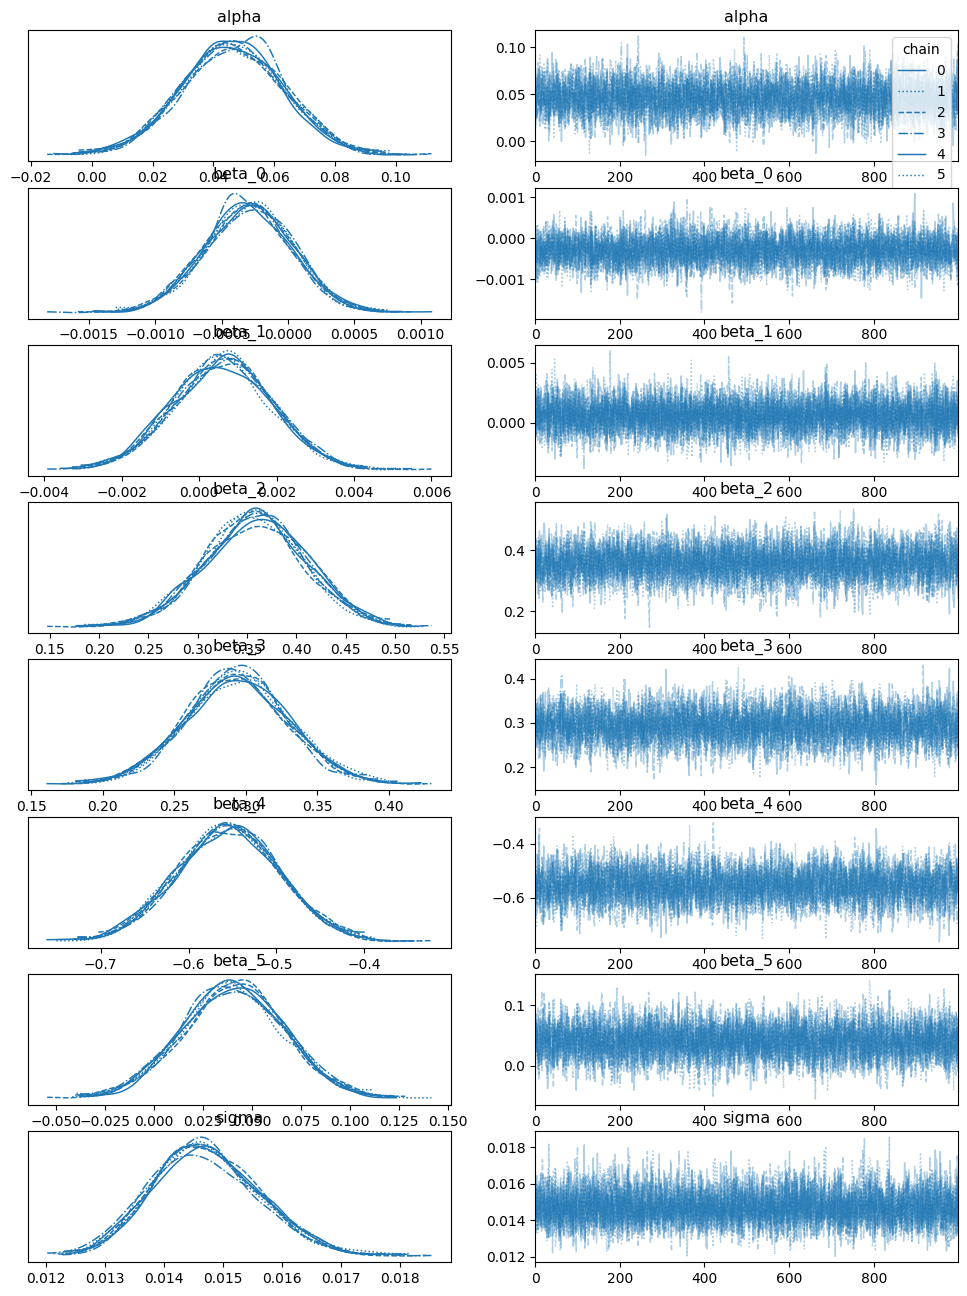

In [12]:
az.plot_trace(idata,legend=True);

<Axes: xlabel='Y_obs'>

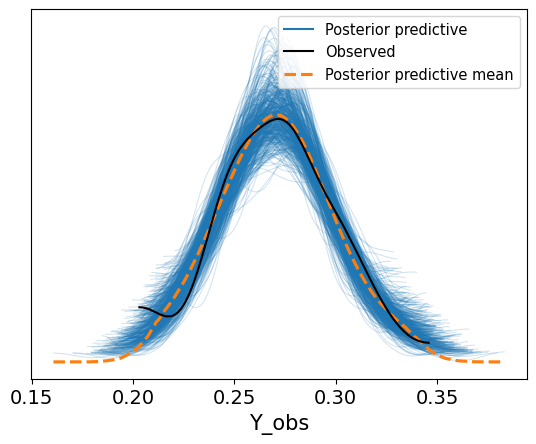

In [13]:
# note need to downsample
az.plot_ppc(posterior_predictive,num_pp_samples=500)

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

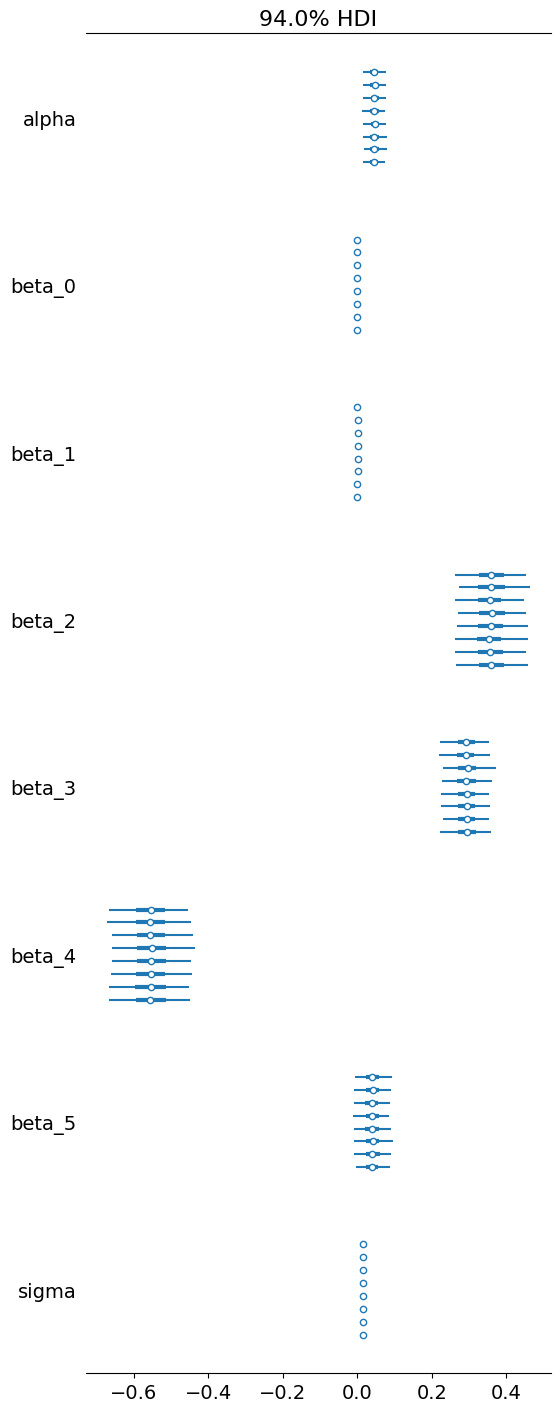

In [14]:
az.plot_forest(idata)

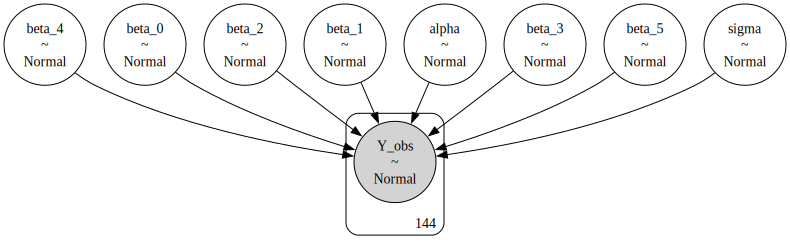

In [15]:
pm.model_to_graphviz(model_0)

In [16]:
# running model with names
with pm.Model(coords={"data":data_model_0}) as model_0_names:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    test = pm.Normal("test", 0,sigma=1,dims="data")
    sigma = pm.Exponential("sigma", 1)
    mu = alpha + pm.math.dot(data_model_0,test)
    y_obs = pm.Normal("y_obs", mu, sigma, observed=y)
    idata_2 = pm.sample(cores=8)
    post = pm.sample_posterior_predictive(idata_2)
    
    

Initializing NUTS using jitter+adapt_diag...
/home/user/baseball/.venv/lib/python3.14/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (8 chains in 8 jobs)
NUTS: [alpha, test, sigma]


Output()

/home/user/baseball/.venv/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 8 chains for 1_000 tune and 1_000 draw iterations (8_000 + 8_000 draws total) took 107 seconds.
Sampling: [y_obs]


Output()

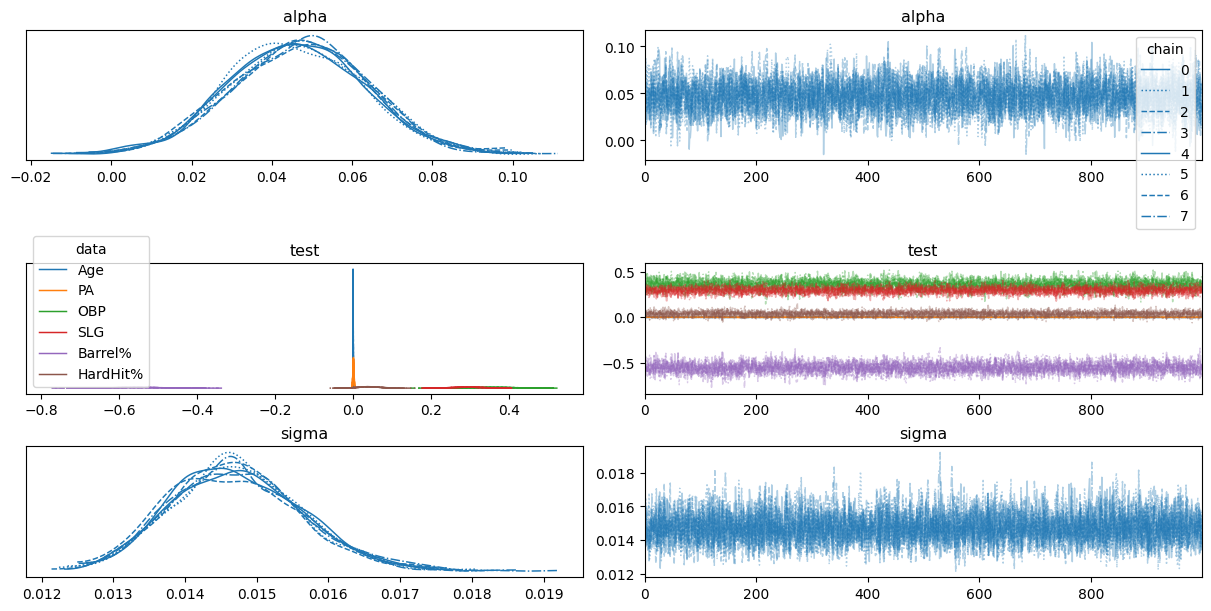

In [17]:
plt.rcParams['figure.constrained_layout.use'] = True
az.plot_trace(idata_2,legend=True);

<Axes: xlabel='y_obs'>

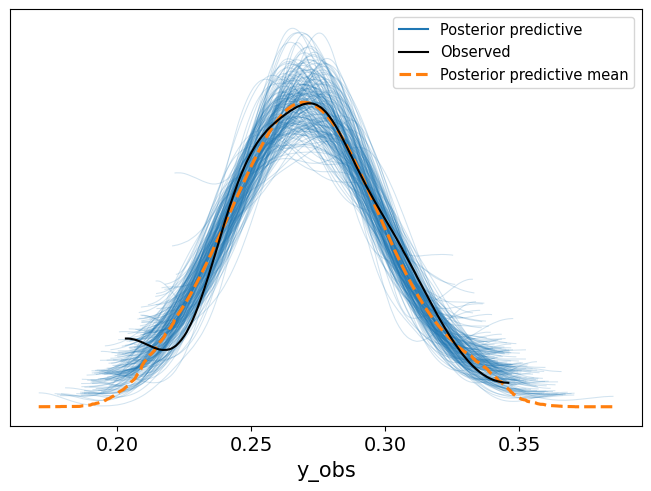

In [18]:
az.plot_ppc(post,num_pp_samples=200)

In [19]:
az.summary(idata_2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.047,0.017,0.016,0.079,0.000,0.000,4919.0,5280.0,1.0
test[Age],-0.000,0.000,-0.001,0.000,0.000,0.000,5528.0,5680.0,1.0
test[PA],0.001,0.001,-0.002,0.003,0.000,0.000,6915.0,5363.0,1.0
test[OBP],0.358,0.050,0.265,0.454,0.001,0.001,4804.0,4934.0,1.0
test[SLG],0.293,0.035,0.229,0.358,0.001,0.000,4288.0,4990.0,1.0
test[Barrel%],-0.551,0.056,-0.654,-0.442,0.001,0.001,4206.0,4913.0,1.0
test[HardHit%],0.039,0.026,-0.009,0.088,0.000,0.000,5199.0,5412.0,1.0
sigma,0.015,0.001,0.013,0.016,0.000,0.000,7374.0,5583.0,1.0
